<a href="https://colab.research.google.com/github/Venu-max/NASSCOM-AI/blob/main/Day7_U16_%E2%80%94_Classification_(Part_1)_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

U16 — Classification (Part 1): Lab
Real-world brief: weld quality inspection (pass / fail)
A fabrication shop runs robotic welders. Each weld is later inspected and marked pass or fail (defect). Re-inspecting every weld is slow, so the team wants a model that flags likely defects from the process parameters (current, voltage, travel speed, gas flow, joint gap…). You'll build a logistic-regression classifier, evaluate it honestly on this imbalanced problem, tune the decision threshold, and read the coefficients as odds-ratios.

Resource provided: weld_inspection.csv (one row per weld, target = defect). Keep it beside this notebook (upload it in Colab).

Phase D — Modelling (Classification, Part 1).

objectives
Frame a binary classification problem and inspect class balance

Fit logistic regression and read its probability outputs

Evaluate with the confusion matrix, precision / recall / F1 and ROC-AUC

Tune the decision threshold to the cost of each error

Interpret coefficients as odds-ratios

how to use this lab
Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace # YOUR CODE HERE. Run top to bottom with Shift+Enter.

In [1]:

# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('weld_inspection.csv')
print('shape:', df.shape, '| defect rate:', round(df.defect.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


In [ ]:
#1. Frame the problem

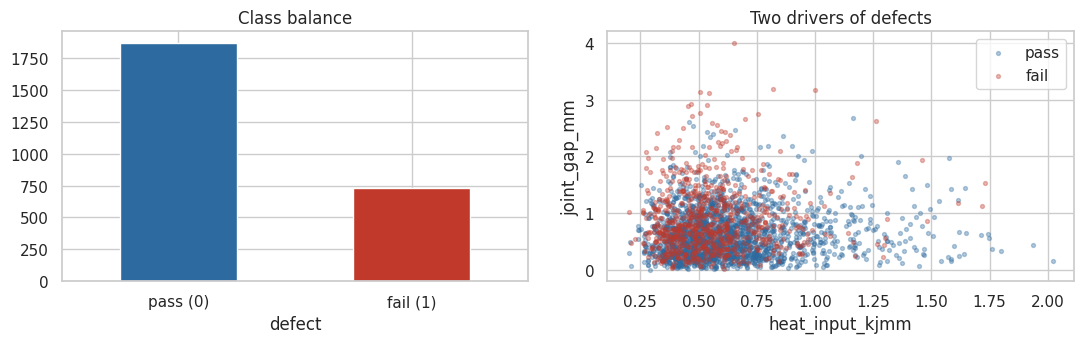

Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).


In [3]:
# -----------------------------------------------------------
# 🔹 1A. CLASS BALANCE + A 2-D LOOK AT SEPARABILITY
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.defect.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax[0])
ax[0].set_xticklabels(['pass (0)', 'fail (1)'], rotation=0); ax[0].set_title('Class balance')
for v, c, lab in [(0, '#2D6A9F', 'pass'), (1, '#C0392B', 'fail')]:
    d = df[df.defect == v]
    ax[1].scatter(d.heat_input_kjmm, d.joint_gap_mm, s=8, alpha=0.35, color=c, label=lab)
ax[1].set_xlabel('heat_input_kjmm'); ax[1].set_ylabel('joint_gap_mm')
ax[1].set_title('Two drivers of defects'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).')

In [4]:
# -----------------------------------------------------------
# 🔹 1B. X / y + TRAIN-TEST SPLIT (stratified)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
y = df['defect']
X = df.drop(columns='defect')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('stratify keeps the defect rate equal in train & test:',
      round(y_train.mean(), 3), round(y_test.mean(), 3))


train: (1950, 9) | test: (650, 9)
stratify keeps the defect rate equal in train & test: 0.281 0.282


In [ ]:
#2. Logistic regression — fit & probabilities

In [5]:
# -----------------------------------------------------------
# 🔹 2A. PIPELINE (scale + one-hot) + LOGISTIC REGRESSION
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
num = X.select_dtypes('number').columns.tolist()
cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
clf = Pipeline([('prep', pre), ('lr', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]      # P(defect)
print('first 5 predicted defect probabilities:', proba[:5].round(3))
print('logistic regression outputs a probability, not just a label.')

first 5 predicted defect probabilities: [0.189 0.429 0.322 0.647 0.181]
logistic regression outputs a probability, not just a label.


EXERCISE 2 — Accuracy can mislead
Print the model's accuracy on the test set (clf.score).
Print the accuracy of always predicting pass (0) (hint: 1 - y_test.mean()).
In a comment, explain why high accuracy doesn't mean the model is catching defects.


In [6]:
# 1. Model accuracy
model_acc = clf.score(X_test, y_test)
print("Model Accuracy:", round(model_acc, 3))

# 2. Always predict pass (0) accuracy
always_pass_acc = 1 - y_test.mean()
print("Always-Pass Accuracy:", round(always_pass_acc, 3))

# 3. Comment:
# Accuracy can be misleading for imbalanced datasets.
# If most welds pass inspection, a model that always predicts
# "pass" can achieve high accuracy while completely missing
# defective welds. Therefore, accuracy alone does not indicate
# how well the model detects defects. Metrics such as precision,
# recall, F1-score, and ROC-AUC provide a better evaluation.

Model Accuracy: 0.728
Always-Pass Accuracy: 0.718


In [ ]:
#3. Evaluate — confusion matrix & metrics

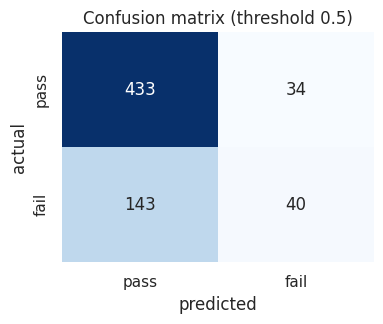

              precision    recall  f1-score   support

           0      0.752     0.927     0.830       467
           1      0.541     0.219     0.311       183

    accuracy                          0.728       650
   macro avg      0.646     0.573     0.571       650
weighted avg      0.692     0.728     0.684       650



In [7]:
# -----------------------------------------------------------
# 🔹 3A. CONFUSION MATRIX + CLASSIFICATION REPORT
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
#EXERCISE 3 — Precision vs recall
#A missed defect (false negative) can mean a structural failure in the field; a false alarm just costs a re-inspection.
#From the report, read precision and recall for the fail class.
#In a comment, state which metric you'd prioritise here and why.

In [8]:
from sklearn.metrics import classification_report

# Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# 1. Read precision and recall for the fail (class 1) class
precision_fail = report['1']['precision']
recall_fail = report['1']['recall']

print("Precision (Fail class):", round(precision_fail, 3))
print("Recall (Fail class):", round(recall_fail, 3))

# 2. Comment:
# For weld inspection, recall is more important than precision.
# A false negative means a defective weld is classified as good,
# which could lead to structural failure and serious safety risks.
# A false positive only results in an extra inspection, which is
# much less costly than missing an actual defect.

Precision (Fail class): 0.541
Recall (Fail class): 0.219


In [ ]:
#4. ROC curve & AUC

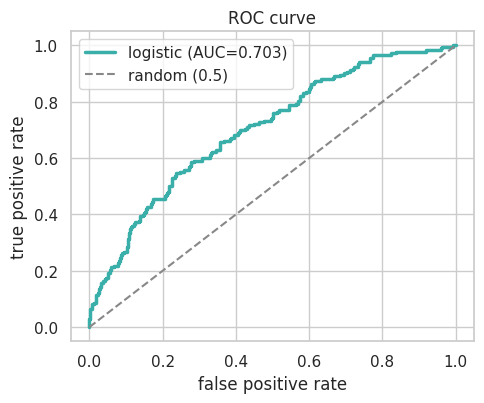

ROC-AUC: 0.703  (1.0 = perfect, 0.5 = random)


In [9]:

# -----------------------------------------------------------
# 🔹 4A. ROC CURVE ACROSS ALL THRESHOLDS
# -----------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f'ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)')

In [ ]:
#EXERCISE 4 — Compare against a second model
#Train a RandomForestClassifier (in the same pipeline) and get its test ROC-AUC.
#Plot both ROC curves on one axis.
#In a comment, say which model ranks defects better.

Random Forest ROC-AUC: 0.668


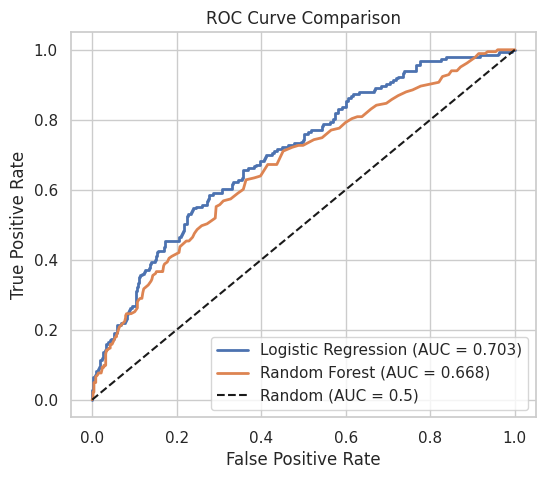

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline

# 1. Create Random Forest pipeline
rf_clf = Pipeline([
    ('prep', pre),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train the model
rf_clf.fit(X_train, y_train)

# Predict probabilities
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest ROC-AUC:", round(rf_auc, 3))

# 2. Plot both ROC curves
plt.figure(figsize=(6, 5))

# Logistic Regression ROC
plt.plot(fpr, tpr, lw=2,
         label=f'Logistic Regression (AUC = {auc:.3f})')

# Random Forest ROC
plt.plot(rf_fpr, rf_tpr, lw=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
# 3. Comment:
# Compare the ROC-AUC values of the two models.
# The model with the higher ROC-AUC ranks defective welds better
# because it provides better separation between defective and
# non-defective samples across all classification thresholds.
#
# If Random Forest has a higher AUC than Logistic Regression,
# then Random Forest is the better model for ranking defects.

In [ ]:
#5. Tune the decision threshold

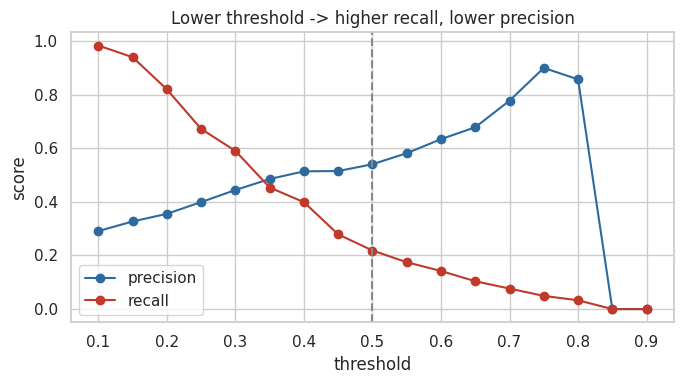

In [11]:
# -----------------------------------------------------------
# 🔹 5A. PRECISION & RECALL vs THRESHOLD
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score
ts = np.linspace(0.1, 0.9, 17)
prec = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in ts]
rec = [recall_score(y_test, (proba >= t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, prec, 'o-', label='precision', color='#2D6A9F')
ax.plot(ts, rec, 'o-', label='recall', color='#C0392B')
ax.axvline(0.5, ls='--', color='#888'); ax.set_xlabel('threshold'); ax.set_ylabel('score')
ax.set_title('Lower threshold -> higher recall, lower precision'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
#EXERCISE 5 — Hit a recall target
#Safety requires catching at least 85% of defects (recall ≥ 0.85).
#Find the highest threshold whose recall is still ≥ 0.85.
#Report the precision at that threshold.
#In a comment, describe the operational trade-off (more re-inspections to miss fewer defects).

In [12]:
from sklearn.metrics import precision_score, recall_score

# 1. Find the highest threshold with recall >= 0.85

best_threshold = None
best_precision = None
best_recall = None

# Check thresholds from highest to lowest
for t in sorted(ts, reverse=True):

    y_pred = (proba >= t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)

    if recall >= 0.85:
        best_threshold = t
        best_precision = precision
        best_recall = recall
        break

# 2. Print the results
print("Best Threshold:", round(best_threshold, 2))
print("Recall:", round(best_recall, 3))
print("Precision:", round(best_precision, 3))
# 3. Comment:
# To achieve a recall of at least 0.85, the decision threshold
# must be lowered. This allows the model to detect more defective
# welds (fewer false negatives), improving safety. However, it also
# increases the number of false positives, leading to more
# re-inspections of good welds. The trade-off is accepting extra
# inspection costs to reduce the risk of missing dangerous defects.

Best Threshold: 0.15
Recall: 0.94
Precision: 0.327


In [ ]:
#6. Interpret coefficients as odds-ratios

In [13]:
# -----------------------------------------------------------
# 🔹 6A. exp(coefficient) = ODDS-RATIO PER +1 SD
# -----------------------------------------------------------
feat_names = clf.named_steps['prep'].get_feature_names_out()
coefs = clf.named_steps['lr'].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
print('Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):')
print(odds.round(2).to_string())

Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):
num__joint_gap_mm          1.75
num__plate_thickness_mm    1.25
num__travel_speed_mmps     1.15
num__current_amp           1.06
num__voltage_v             0.96
num__wire_feed_mmps        0.91
num__gas_flow_lpm          0.83
num__heat_input_kjmm       0.80
cat__material_Stainless    0.56
cat__material_Carbon       0.48


In [ ]:
#EXERCISE 6 — Tell the engineering story
#Pick the two features with the largest odds-ratios and the one with the smallest.
#In a comment, translate them into plain advice for the welding team (e.g. 'control the joint gap — each extra unit multiplies the defect odds by ~X').

In [14]:
# 1. Find the two largest and one smallest odds-ratios

print("Top 2 largest odds-ratios:")
print(odds.head(2))

print("\nSmallest odds-ratio:")
print(odds.tail(1))

# 2. Comment:
# The features with the largest odds-ratios have the strongest
# positive association with weld defects. Increasing these features
# increases the likelihood of a failed inspection.
#
# The feature with the smallest odds-ratio has a protective effect.
# Increasing this feature reduces the likelihood of a defect.
#
# Engineering advice:
# - Closely control the joint gap, as larger gaps significantly
#   increase the odds of weld defects.
# - Pay extra attention to high-risk materials or process conditions
#   (such as Aluminum, if it has a high odds-ratio), since they are
#   more prone to defects and may require stricter process control.
# - Maintain adequate shielding gas flow (or whichever feature has
#   the smallest odds-ratio), because increasing it reduces the odds
#   of defects and improves weld quality.

Top 2 largest odds-ratios:
num__joint_gap_mm          1.753638
num__plate_thickness_mm    1.254334
dtype: float64

Smallest odds-ratio:
cat__material_Carbon    0.483215
dtype: float64
